In [49]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot4 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import importlib



In [50]:
# A proper data to MC comparison contains three element:
# Standard nu overlay: this is all the beam neutrinos interacting in the MicroBooNE detector. This is the dominate component of the prediction.
# Dirt overlay: this is all beam neutrinos interacting outside the MicroBooNE detector.
# EXT: This is cosmic induced events where there was no beam neutrino in the detector.

In [51]:
# For this demo, you will need the following files:

# Data:
# checkout_MCC9.10_Run4b_NuMI_beam_on_RHC_data_surprise_v10_04_07_09_reco2_hist.root

# nu overlay:
# checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist.root

# dirt:
# checkout_MCC9.10_Run4a4c_NuMI_RHC_dirt_overlay_surprise_reco2_hist_4b.root

# EXT:
# checkout_MCC9.10_Run4b_NuMI_beam_off_RHC_data_surprise_v10_04_07_09_reco2_hist.root

# All of these locations can be found at the wiki: https://cdcvs.fnal.gov/redmine/projects/uboone-physics-analysis/wiki/MCC910_Samples
# I advise you use the "wc only" files, they are much smaller and have all the information that you need

In [52]:

# The POT defines "how much beam" we got, it is what is need to normalize data and MC.
data_pot = 2.056e+20
#2.513e+20 full 4b
#4.991e+19 open data 4b

# EXT is cosmic induced events with no neutrino in the detector. This is "real data", but makes up part of our MC prediction (confusing!)
# We take data without the beam to estimate this.
# The "POT" of the EXT is defined by rescaling the number of triggered events in the EXT sample to the Data sample
ext_pot = 3.827191989537554e+21

#ext_pot = data_pot*15769216.925000/5425918.0

# In the future, I can teach you how to obtain these for any sample, but just use these as is for now.

In [53]:
# Define the variables that we will load in
# Here, I define seperate sets for data and MC in some trees; data does not have weights or truth information.

eval_vars = ["match_isFC","run","subrun","event"]
eval_mc_vars = ["weight_spline","weight_cv"]

pf_eval_vars = ["reco_muonMomentum"]
pf_eval_mc_vars = ["truth_isCC","truth_nuPdg", "truth_nuEnergy"]

bdt_vars = [
    "mip_energy",
    "mip_angle_beam", 
    "spt_angle_vertical",
    "nue_score", 
    "numu_score", 
    "numu_cc_flag",
    "numu_1_score",
    "numu_cc_3_track_length",
    "numu_cc_3_max_length_all",
    "cosmict_2_dQ_dx_front",
    "cosmict_2_dQ_dx_end",
    "cosmict_2_angle_beam",
    "cosmict_2_phi",
    "numu_cc_3_max_length",
    "numu_cc_3_max_muon_length",

    "numu_cc_flag_1",
    "numu_cc_flag_2",
    "numu_cc_flag_3",
    "cosmict_flag",
    
    "numu_cc_1_length",
    "numu_cc_1_direct_length",
    "numu_cc_2_length",
    "numu_cc_2_total_length",

    #"nc_pio_score"
]

kine_vars = ["kine_reco_Enu"]


In [54]:
def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

In [55]:
train_vars = [
    'mip_energy', 'spt_angle_vertical',
    'nue_score', 'numu_score', 'numu_1_score',
    'numu_cc_3_track_length',
    'numu_cc_3_max_length', 'numu_cc_3_max_muon_length',

    'cosmict_2_dQ_dx_end',
    'cosmict_2_phi',
    'cosmict_flag',

    'stm_eventtype', 'stm_lowenergy',
    'stm_LM', 'stm_TGM', 'stm_STM',
    'stm_FullDead', 'stm_clusterlength',

    'evtTimeNS_cor', 'merge_time', 'times_adjusted',

    'reco_muonMomentum', 'reco_protonMomentum',
    'reco_Eproton', #'Ehadron',

    'reco_nuvtxX', 'reco_nuvtxY', 'reco_nuvtxZ',
    'reco_muonvtxX', 'reco_muonvtxY', 'reco_muonvtxZ',

    'reco_showerMomentum',
    'reco_Ntrack',

    'reco_muon_phi',
    'reco_muon_cosphi',

    'reco_nu_numi_theta',

    'con_track_1_KE',
    'allcon_track_1_KE',

    'prim_e_1_KE', 'prim_e_2_KE',
    'allcon_e_1_KE', 'allcon_e_2_KE',

    'g_2_KE',
    'prim_g_1_KE', 'prim_g_2_KE',

    'pf_con_muon_1_E', 'pf_con_muon_2_E',

    'pf_p_1_E',
    'pf_prim_p_1_E',

    'reco_pi0_mom',
    'reco_pi0_mom_2',

    #'kine_reco_Enu',
    'kine_pio_flag',
    'kine_pio_vtx_dis',
    'kine_pio_energy_1', 'kine_pio_theta_1',
    'kine_pio_phi_1', 'kine_pio_dis_1'
]

# Load in main files

In [ ]:
overlay_df = pd.read_pickle("run5_overlay_df.pkl")
data_df = pd.read_pickle("run5_data_df.pkl")
dirt_df = pd.read_pickle("run5_dirt_df.pkl")
ext_df = pd.read_pickle("run5_ext_df.pkl")

In [ ]:
import xgboost as xgb
model_VtxAct = xgb.Booster({'nthread': 4})  # init model
model_VtxAct.load_model('flux_vz_gt500.json')  # load data, need to specify your .json location

# dataframe, xgboost bdt model, list of variables used by the bdt, what the bdt score gets saved as in the output dfdataframe
def add_bdt_scores(df,model,names,bdtvarname):
    print(names)
    d_pred_df = df[names].replace([np.inf, -np.inf], np.nan)
    d_reg = xgb.DMatrix(d_pred_df, enable_categorical=True)
    d_pred = model.predict(d_reg)
    df[bdtvarname] = d_pred
    
    kine_reco_Enu = df["kine_reco_Enu"].to_numpy()
    bdt_score = df[bdtvarname].to_numpy()
    
    for i in tqdm(range(len(kine_reco_Enu))):
        if kine_reco_Enu[i]<0: 
            bdt_score[i] = -999

    df[bdtvarname] = bdt_score

    return df

model_features = model_VtxAct.feature_names
if model_features is None:
    raise ValueError("Model has no feature names; need the original training feature list.")

# Ensure all required features exist
missing = [c for c in model_features if c not in overlay_df.columns]
if missing:
    raise KeyError(f"Missing required features: {missing}")

print(model_features)


'''add_bdt_scores(overlay_df, model_VtxAct, model_features, "bdt_score")
add_bdt_scores(data_df, model_VtxAct, model_features, "bdt_score")
add_bdt_scores(dirt_df, model_VtxAct, model_features, "bdt_score")
add_bdt_scores(ext_df, model_VtxAct, model_features, "bdt_score")'''

['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_dis', 'kine_pio_energy_1', 'kine_pio_theta_1', 'kine_pio_dis_1']
['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_d

100%|██████████| 795989/795989 [00:00<00:00, 2416815.14it/s]


['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_dis', 'kine_pio_energy_1', 'kine_pio_theta_1', 'kine_pio_dis_1']


100%|██████████| 664219/664219 [00:00<00:00, 2405592.92it/s]


['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_dis', 'kine_pio_energy_1', 'kine_pio_theta_1', 'kine_pio_dis_1']


100%|██████████| 123411/123411 [00:00<00:00, 2629437.87it/s]


['mip_energy', 'spt_angle_vertical', 'nue_score', 'numu_score', 'numu_cc_3_track_length', 'numu_cc_3_max_length', 'numu_cc_3_max_muon_length', 'stm_eventtype', 'stm_lowenergy', 'stm_clusterlength', 'merge_time', 'reco_Eproton', 'reco_showerMomentum', 'reco_Ntrack', 'reco_muon_cosphi', 'prim_e_1_KE', 'prim_e_2_KE', 'allcon_e_1_KE', 'allcon_e_2_KE', 'g_2_KE', 'prim_g_1_KE', 'prim_g_2_KE', 'pf_p_1_E', 'reco_pi0_mom', 'reco_pi0_mom_2', 'kine_pio_flag', 'kine_pio_vtx_dis', 'kine_pio_energy_1', 'kine_pio_theta_1', 'kine_pio_dis_1']


100%|██████████| 2132536/2132536 [00:00<00:00, 2675759.35it/s]


,mip_energy,mip_angle_beam,spt_angle_vertical,nue_score,numu_score,numu_cc_flag,numu_1_score,numu_cc_3_track_length,numu_cc_3_max_length_all,cosmict_2_dQ_dx_front,...,reco_pi0_phi,reco_pi0_cosphi,reco_pi0_theta,reco_pi0_costheta,reco_pi0_costheta_CM,gamma_1_mom_0,gamma_2_mom_0,gamma_lead_mom_0,gamma_trail_mom_0,bdt_score
0,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
1,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
2,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
3,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
4,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2132531,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
2132532,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
2132533,-1.0,-1.0,-1.0,-15.0,-3.340668,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0
2132534,-1.0,-1.0,-1.0,-15.0,-3.821578,-1.0,-0.4,-1.0,-1.0,-1.0,...,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-999.0


In [ ]:
'''file_name = "checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_5.root"
f_overlay = uproot.open(file_name)["wcpselection"]
f_overlay_eval = f_overlay["T_eval"].arrays(["weight_spline","weight_cv"], library='pd')
overlay_df["weight_spline"] = f_overlay_eval["weight_spline"].to_numpy()
overlay_df["weight_cv"] = f_overlay_eval["weight_cv"].to_numpy()
'''

In [ ]:
'''# NOTE: when you start including multiple runs (4a,4b,...), the POT scaling need to be calculated seperate for each!
# This defines the POT scaling of this MC sample to the data

#Ext
ext_df["POTscaled"] = [data_pot/ext_pot for i in range(ext_df.shape[0])]
# EXT does not have event weights, so just need to do the POT scaling
ext_df["net_weight_POTscaled"] = ext_df["POTscaled"].to_numpy()

#dirt
file_name = "checkout_prodgenie_numi_fhc_dirt_new_flux_overlay_run_4cd_5_reco2_reco2_hist_5.root"
dirt_df["net_weight"] = dirt_df["weight_cv"].to_numpy()*dirt_df["weight_spline"].to_numpy()
f_dirt = uproot.open(file_name)["wcpselection"]
f_dirt_pot = f_dirt["T_pot"].arrays("pot_tor875good", library='pd')
dirt_POT = np.sum(f_dirt_pot["pot_tor875good"].to_numpy()) 
dirt_df["POTscaled"] = [data_pot/dirt_POT for i in range(dirt_df.shape[0])]
dirt_df["net_weight_POTscaled"] = dirt_df["net_weight"].to_numpy()*dirt_df["POTscaled"].to_numpy()

#overlay
file_name = "checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_5.root"
overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()
f_overlay = uproot.open(file_name)["wcpselection"]
f_overlay_pot = f_overlay["T_pot"].arrays("pot_tor875good", library='pd')
overlay_POT = np.sum(f_overlay_pot["pot_tor875good"].to_numpy()) 
overlay_df["POTscaled"] = [data_pot/overlay_POT for i in range(overlay_df.shape[0])]
overlay_df["net_weight_POTscaled"] = overlay_df["net_weight"].to_numpy()*overlay_df["POTscaled"].to_numpy()'''

In [83]:
def scaling_recalc(data_run4b_super_df):
    
    em_charge_scale = 0.95
    data_run4b_super_df["pio_mass"] = data_run4b_super_df['kine_pio_mass'].to_numpy()* em_charge_scale
    data_run4b_super_df["em_charge_scale"] = np.ones_like(data_run4b_super_df['kine_pio_mass'].to_numpy())* em_charge_scale
    
    #Get the reconstructed neutrino energy, for data we need to apply a scaling to the shower energy
    corrected_kine_reco_Enus = []
    energy_info_lists = data_run4b_super_df["kine_energy_info"].to_numpy()
    energy_lists = data_run4b_super_df["kine_energy_particle"].to_numpy()
    pdg_lists = data_run4b_super_df["kine_particle_type"].to_numpy()
    add_energies = data_run4b_super_df["kine_reco_add_energy"].to_numpy()
    for i in tqdm(range(data_run4b_super_df.shape[0])):
        corrected_kine_reco_Enu = 0.
        energy_list = energy_lists[i]
        pdg_list = pdg_lists[i]
        energy_info_list = energy_info_lists[i]
        for j in range(len(energy_list)):
            if energy_info_list[j] == 2 and pdg_list[j] == 11:
                corrected_kine_reco_Enu += em_charge_scale * energy_list[j]
            else:
                corrected_kine_reco_Enu += energy_list[j]
        corrected_kine_reco_Enu += add_energies[i]
        
        corrected_kine_reco_Enus.append(corrected_kine_reco_Enu) 

    data_run4b_super_df["kine_reco_Enu"] = corrected_kine_reco_Enus


In [84]:

import awkward as ak

def expand_momentum_col(df, col, n=4, prefix=None):
    prefix = prefix or col
    arr = df[col]
    ak_arr = ak.Array(arr)
    ak_arr = ak.fill_none(ak_arr, [np.nan] * n)
    ak_arr = ak.pad_none(ak_arr, n, clip=True)
    for i in range(n):
        df[f"{prefix}_{i}"] = ak.to_numpy(ak_arr[:, i])
    df.drop(columns=[col], inplace=True)



In [85]:
def plot_var_basic(var,nbins,min_bin,max_bin,force_legend='',add_query='',logy=False):

    # Make the bins
    bins = np.linspace(min_bin, max_bin, num=nbins+1)

    # Make the reco selection
    query = "kine_reco_Enu>-9999999999999999999"
    if add_query!='': query += ' and ' + add_query 

    # Make histograms for overlay, dirt and EXT
    y_overlay,x = np.histogram(overlay_df.query(query)[var].to_numpy(),bins=bins,density=False,weights=overlay_df.query(query)["net_weight_POTscaled"].to_numpy())
    y_dirt,x = np.histogram(dirt_df.query(query)[var].to_numpy(),bins=bins,density=False,weights=dirt_df.query(query)["net_weight_POTscaled"].to_numpy())    
    y_ext,x = np.histogram(ext_df.query(query)[var].to_numpy(),bins=bins,density=False,weights=ext_df.query(query)["net_weight_POTscaled"].to_numpy())

    # The total prediction is the sum of the three components
    y_all = np.array(y_overlay)+np.array(y_dirt)+np.array(y_ext)

    # Now same for the data
    y_data,x = np.histogram(data_df.query(query)[var].to_numpy(),bins=bins,density=False)

    # Start the plotting!
    plt.figure()     
    plt.stairs(y_all,x,color="black",alpha=0.8)
    plt.stairs(y_overlay+y_ext+y_dirt,x,baseline=y_overlay+y_ext,fill=True,color="violet",label="DIRT",alpha=0.5)
    plt.stairs(y_overlay+y_ext,x,baseline=y_overlay,fill=True,color="brown",label="EXT",alpha=0.5)
    plt.stairs(y_overlay,x,fill=True,color="green",label=r"$\nu$",alpha=0.5)   
    
    plt.errorbar(get_bin_centers(x),y_data,yerr=np.sqrt(y_data),ms=8, lw=1,fmt='.',ecolor = 'black',color='black', capsize=2, capthick=1, label="Data")

    if force_legend=='outside': plt.legend(reverse=True, loc='center left', bbox_to_anchor=(1, 0.5)) 
    elif force_legend !='' and force_legend !='off': plt.legend(reverse=True, loc=force_legend)
    elif force_legend !='off': plt.legend(reverse=True)
    if logy: plt.yscale('log')
        
    plt.xlim(min_bin,max_bin)
    plt.xlabel(var)
    plt.ylabel("Counts")
    plt.show()

    print("Data/MC",np.sum(y_data)/np.sum(y_all))


In [101]:
def plot_var_breakdown(var,nbins,min_bin,max_bin,force_legend='',add_query='',logy=False, bdt_threshold=None):

    # Make the bins
    bins = np.linspace(min_bin, max_bin, num=nbins+1)
    bdt_candidates = [
        "bdt_score"
    ]
    bdt_var = next((c for c in bdt_candidates if c in overlay_df.columns), None)
    if bdt_var is None:
        raise KeyError("No BDT score column found in overlay_df. Check overlay_df.columns.tolist().")
    
    # Make the reco selection
    query = "index>=0"
    if add_query!='': query += ' and ' + add_query 

    # Apply BDT cut to overlay - use .loc instead of .query for columns with backslashes
    if bdt_var is not None and bdt_threshold is not None:
        # First apply base query, then BDT filter with .loc
        overlay_subset = overlay_df.query(query) if query else overlay_df
        overlay_subset = overlay_subset.loc[overlay_subset[bdt_var] > bdt_threshold]
        
        # Apply to data if it has the column
        if bdt_var in data_df.columns:
            data_subset = data_df.query(query) if query else data_df
            data_subset = data_subset.loc[data_subset[bdt_var] > bdt_threshold]
        else:
            print(f"WARNING: data_df doesn't have {bdt_var}, using base query only")
            data_subset = data_df.query(query) if query else data_df
        
        # Apply to dirt if it has the column
        if bdt_var in dirt_df.columns:
            dirt_subset = dirt_df.query(query) if query else dirt_df
            dirt_subset = dirt_subset.loc[dirt_subset[bdt_var] > bdt_threshold]
        else:
            print(f"WARNING: dirt_df doesn't have {bdt_var}, using base query only")
            dirt_subset = dirt_df.query(query) if query else dirt_df
        
        # Apply to ext if it has the column
        if bdt_var in ext_df.columns:
            ext_subset = ext_df.query(query) if query else ext_df
            ext_subset = ext_subset.loc[ext_subset[bdt_var] > bdt_threshold]
        else:
            print(f"WARNING: ext_df doesn't have {bdt_var}, using base query only")
            ext_subset = ext_df.query(query) if query else ext_df
    else:
        overlay_subset = overlay_df.query(query) if query else overlay_df
        data_subset = data_df.query(query) if query else data_df
        dirt_subset = dirt_df.query(query) if query else dirt_df
        ext_subset = ext_df.query(query) if query else ext_df
    
    y_overlay, x = np.histogram(
        overlay_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=overlay_subset["net_weight_POTscaled"].to_numpy(),
    )

    y_dirt, x = np.histogram(
        dirt_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=dirt_subset["net_weight_POTscaled"].to_numpy(),
    )

    y_ext, x = np.histogram(
        ext_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=ext_subset["net_weight_POTscaled"].to_numpy(),
    )
    
    # Now, we will also make sub-selections for the overlay
    # This is neutral current interaction
    y_nc_overlay,x = np.histogram(overlay_subset.query("truth_isCC==0")[var].to_numpy(),bins=bins,density=False,weights=overlay_subset.query("truth_isCC==0")["net_weight_POTscaled"].to_numpy())
    # Charged current electron neutrino
    y_nue_overlay,x = np.histogram(overlay_subset.query("truth_isCC==1 and abs(truth_nuPdg)==12")[var].to_numpy(),bins=bins,density=False,weights=overlay_subset.query("truth_isCC==1 and abs(truth_nuPdg)==12")["net_weight_POTscaled"].to_numpy())
    # Charged current anti-muon neutrino
    y_numubar_overlay,x = np.histogram(overlay_subset.query("truth_isCC==1 and truth_nuPdg==-14")[var].to_numpy(),bins=bins,density=False,weights=overlay_subset.query("truth_isCC==1 and truth_nuPdg==-14")["net_weight_POTscaled"].to_numpy())
    # Charged current muon neutrino
    y_numu_overlay,x = np.histogram(overlay_subset.query("truth_isCC==1 and truth_nuPdg==14")[var].to_numpy(),bins=bins,density=False,weights=overlay_subset.query("truth_isCC==1 and truth_nuPdg==14")["net_weight_POTscaled"].to_numpy())

    # If you are doing breakdowns, it is always good your catagories sum to the total
    print(np.sum(y_overlay),np.sum(y_numu_overlay+y_numubar_overlay+y_nue_overlay+y_nc_overlay))
    
    # The total prediction is the sum of the three components
    y_all = np.array(y_overlay)+np.array(y_dirt)+np.array(y_ext)

    # Now same for the data - NO WEIGHTS, it's real data!
    y_data,x = np.histogram(data_subset[var].to_numpy(),bins=bins,density=False)

    # Start the plotting!
    plt.figure()     
    plt.stairs(y_all,x,color="black",alpha=0.8)
    plt.stairs(y_overlay+y_ext+y_dirt,x,baseline=y_overlay+y_ext,fill=True,color="violet",label="DIRT",alpha=0.5)
    plt.stairs(y_overlay+y_ext,x,baseline=y_overlay,fill=True,color="brown",label="EXT",alpha=0.5)

    plt.stairs(y_numu_overlay+y_numubar_overlay+y_nue_overlay+y_nc_overlay,x,baseline=y_numu_overlay+y_numubar_overlay+y_nue_overlay,fill=True,color="dodgerblue",label=r"NC",alpha=0.5)
    plt.stairs(y_numu_overlay+y_numubar_overlay+y_nue_overlay,x,baseline=y_numu_overlay+y_numubar_overlay,fill=True,color="orange",label=r"CC$\nu_e/\bar{\nu}_e$",alpha=0.8)
    plt.stairs(y_numu_overlay+y_numubar_overlay,x,baseline=y_numu_overlay,fill=True,color="forestgreen",label=r"CC$\bar{\nu}_\mu$",alpha=0.8) 
    plt.stairs(y_numu_overlay,x,fill=True,color="green",label=r"CC$\nu_\mu$",alpha=0.5)   
    
    plt.errorbar(get_bin_centers(x),y_data,yerr=np.sqrt(y_data),ms=8, lw=1,fmt='.',ecolor = 'black',color='black', capsize=2, capthick=1, label="Data")

    if force_legend=='outside': plt.legend(reverse=True, loc='center left', bbox_to_anchor=(1, 0.5)) 
    elif force_legend !='' and force_legend !='off': plt.legend(reverse=True, loc=force_legend)
    elif force_legend !='off': plt.legend(reverse=True)
    if logy: plt.yscale('log')
        
    plt.xlim(min_bin,max_bin)
    plt.xlabel(var)
    plt.ylabel("Counts")
    plt.show()

    print("Data/MC",np.sum(y_data)/np.sum(y_all))

2449.595554540505 2449.5955545405095


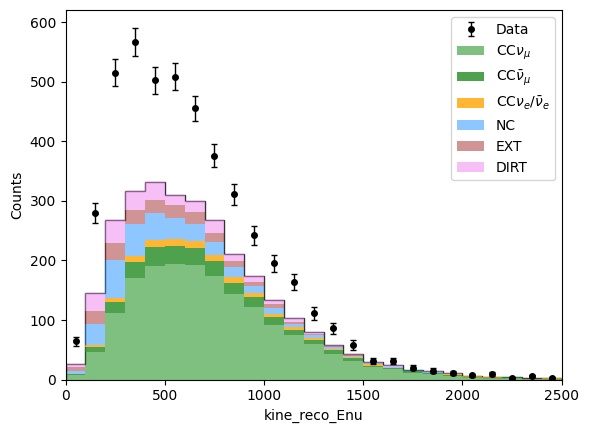

Data/MC 1.5859387470458923


In [105]:

# Generic selection
#plot_var_basic("kine_reco_Enu",25,0,2500,force_legend='',add_query='')
plot_var_breakdown("kine_reco_Enu",25,0,2500,force_legend='',add_query='', bdt_threshold=0.6)


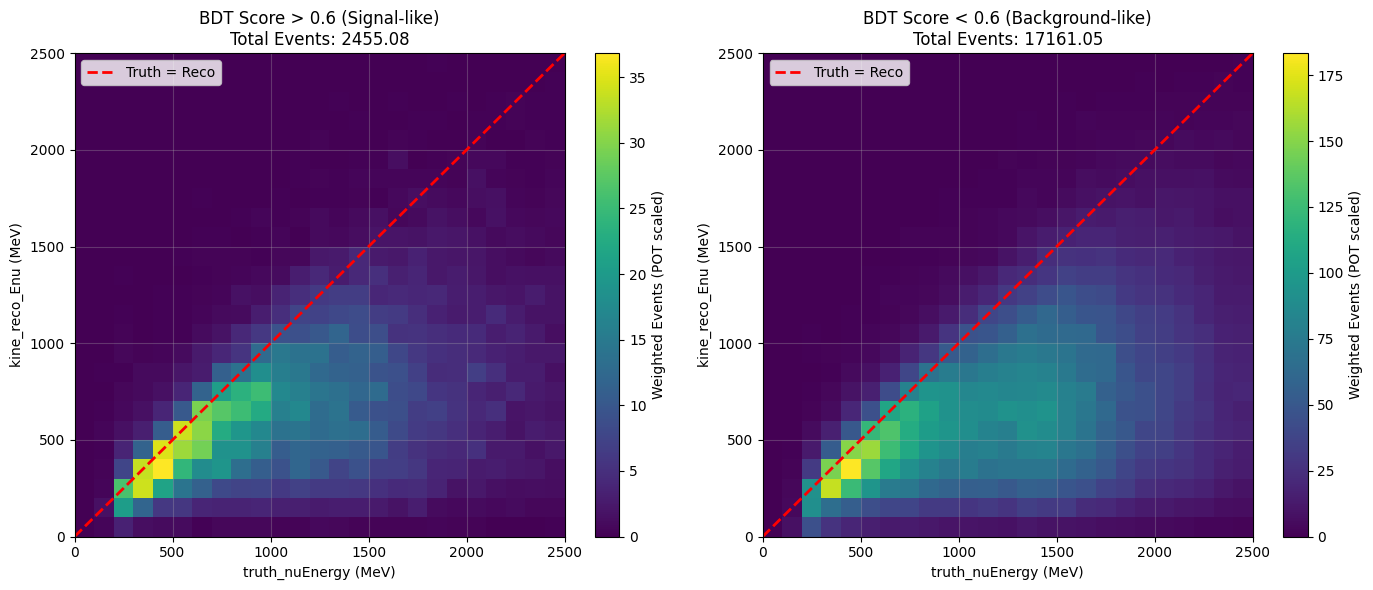


BDT Score > 0.6 (Signal-like):
  Total weighted events: 2455.08
  Mean truth energy: 1372.82 MeV
  Mean reco energy: 711.90 MeV

BDT Score < 0.6 (Background-like):
  Total weighted events: 17161.05
  Mean truth energy: 1689.25 MeV
  Mean reco energy: 786.36 MeV


In [88]:
# Plot truth_nuEnergy vs kine_reco_Enu for different BDT score regions
def plot_truth_vs_reco_energy_with_bdt():
    bdt_var = "bdt_score"
    
    # Define the query to select valid events
    query = "kine_reco_Enu > 0 and truth_nuEnergy > 0"
    
    # Filter overlay, dirt, and ext for valid events
    overlay_valid = overlay_df.query(query)
    
    # Split by BDT score
    mask_high = overlay_valid[bdt_var] > 0.6
    mask_low = overlay_valid[bdt_var] < 0.6
    
    overlay_high = overlay_valid.loc[mask_high]
    overlay_low = overlay_valid.loc[mask_low]
    
    # Create 2D histograms
    bins = [25, 25]
    ranges = [[0, 2500], [0, 2500]]
    
    # High BDT score (> 0.6)
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist2d(overlay_high["truth_nuEnergy"].to_numpy(), 
               overlay_high["kine_reco_Enu"].to_numpy(),
               bins=bins, range=ranges, 
               weights=overlay_high["net_weight_POTscaled"].to_numpy(),
               cmap='viridis')
    plt.colorbar(label='Weighted Events (POT scaled)')
    plt.plot([0, 2500], [0, 2500], 'r--', linewidth=2, label='Truth = Reco')
    plt.xlabel('truth_nuEnergy (MeV)')
    plt.ylabel('kine_reco_Enu (MeV)')
    plt.title(f'BDT Score > 0.6 (Signal-like)\nTotal Events: {np.sum(overlay_high["net_weight_POTscaled"]):.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Low BDT score (< 0.6)
    plt.subplot(1, 2, 2)
    plt.hist2d(overlay_low["truth_nuEnergy"].to_numpy(), 
               overlay_low["kine_reco_Enu"].to_numpy(),
               bins=bins, range=ranges,
               weights=overlay_low["net_weight_POTscaled"].to_numpy(),
               cmap='viridis')
    plt.colorbar(label='Weighted Events (POT scaled)')
    plt.plot([0, 2500], [0, 2500], 'r--', linewidth=2, label='Truth = Reco')
    plt.xlabel('truth_nuEnergy (MeV)')
    plt.ylabel('kine_reco_Enu (MeV)')
    plt.title(f'BDT Score < 0.6 (Background-like)\nTotal Events: {np.sum(overlay_low["net_weight_POTscaled"]):.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nBDT Score > 0.6 (Signal-like):")
    print(f"  Total weighted events: {np.sum(overlay_high['net_weight_POTscaled']):.2f}")
    print(f"  Mean truth energy: {np.average(overlay_high['truth_nuEnergy'], weights=overlay_high['net_weight_POTscaled']):.2f} MeV")
    print(f"  Mean reco energy: {np.average(overlay_high['kine_reco_Enu'], weights=overlay_high['net_weight_POTscaled']):.2f} MeV")
    
    print(f"\nBDT Score < 0.6 (Background-like):")
    print(f"  Total weighted events: {np.sum(overlay_low['net_weight_POTscaled']):.2f}")
    print(f"  Mean truth energy: {np.average(overlay_low['truth_nuEnergy'], weights=overlay_low['net_weight_POTscaled']):.2f} MeV")
    print(f"  Mean reco energy: {np.average(overlay_low['kine_reco_Enu'], weights=overlay_low['net_weight_POTscaled']):.2f} MeV")

plot_truth_vs_reco_energy_with_bdt()

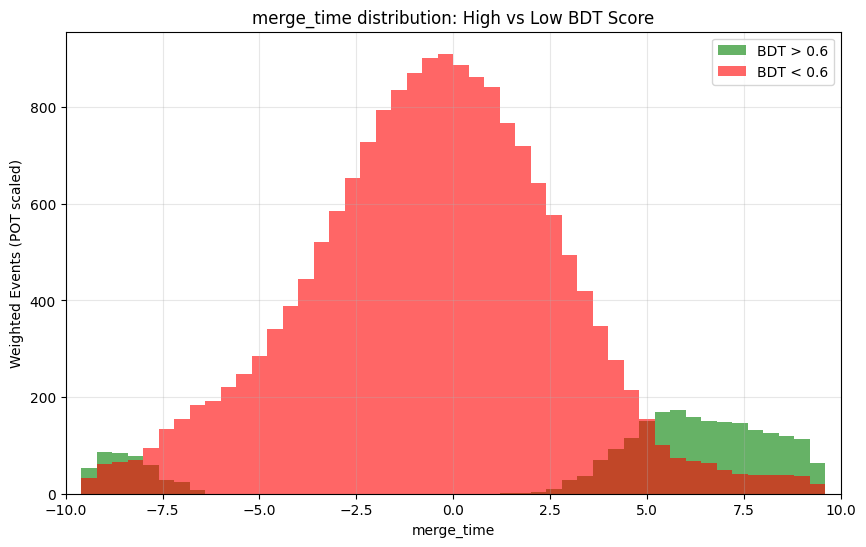

Events with BDT > 0.6: 2422.59
Events with BDT < 0.6: 17472.92


In [89]:
# Plot merge_time with BDT score cuts
def plot_merge_time_with_bdt_cuts():
    var = "merge_time"
    bdt_var = "bdt_score"
    nbins = 50
    min_bin = -10
    max_bin = 10

    bins = np.linspace(min_bin, max_bin, num=nbins + 1)

    mask_high = overlay_df[bdt_var] > 0.6
    mask_low  = overlay_df[bdt_var] < 0.6

    y_high, x = np.histogram(
        overlay_df.loc[mask_high, var].to_numpy(),
        bins=bins,
        density=False,
        weights=overlay_df.loc[mask_high, "net_weight_POTscaled"].to_numpy(),
    )

    y_low, x = np.histogram(
        overlay_df.loc[mask_low, var].to_numpy(),
        bins=bins,
        density=False,
        weights=overlay_df.loc[mask_low, "net_weight_POTscaled"].to_numpy(),
    )
    # Plot
    plt.figure(figsize=(10, 6))
    plt.stairs(y_high, x, fill=True, color="green", label="BDT > 0.6", alpha=0.6)
    plt.stairs(y_low, x, fill=True, color="red", label="BDT < 0.6", alpha=0.6)
    
    plt.legend()
    plt.xlim(min_bin, max_bin)
    plt.xlabel(var)
    plt.ylabel("Weighted Events (POT scaled)")
    plt.title(f"{var} distribution: High vs Low BDT Score")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Events with BDT > 0.6: {np.sum(y_high):.2f}")
    print(f"Events with BDT < 0.6: {np.sum(y_low):.2f}")

plot_merge_time_with_bdt_cuts()

<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
C:\Users\andre\AppData\Local\Temp\ipykernel_23232\1178492307.py:67: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x1, gaus(x1, *popt), color='orange', label='numuCC:' + '\n' + f"$\mu$={round(popt[1],2)}, $\\sigma$={round(abs(popt[2]),2)}")
C:\Users\andre\AppData\Local\Temp\ipykernel_23232\1178492307.py:70: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x2, gaus(x2, *popt2), color='green', label='CCpi0:' + '\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")
C:\Users\andre\AppData\Local\Temp\ipykernel_23232\1178492307.py:73: SyntaxWarning: invalid es

numuCC: Gaussian      mean: -0.0015   std: 2.6266   C: 0.0253
CCpi0: Gaussian      mean: 0.0962   std: 2.3935   C: 0.0203
NCpi0: Gaussian      mean: -0.5214   std: 2.6904   C: 0.0271
loose nueCC: Gaussian      mean: 0.0244   std: 2.5356   C: 0.0194


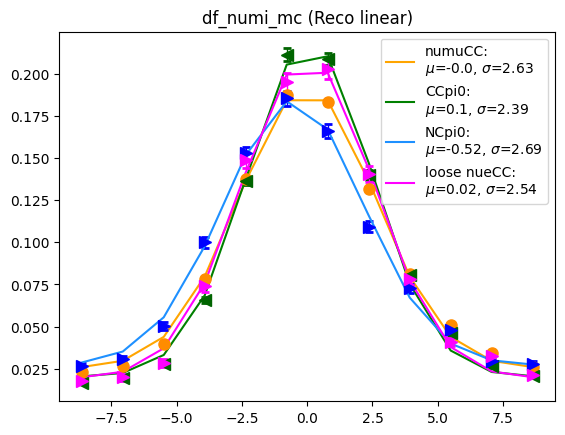

numuCC: Gaussian      mean: 0.0072   std: 2.9365   C: 0.0331
CCpi0: Gaussian      mean: 0.2833   std: 2.7069   C: 0.0326
NCpi0: Gaussian      mean: -1.3427   std: 3.4712   C: 0.0441
loose nueCC: Gaussian      mean: -1.3715   std: 2.7826   C: 0.0371


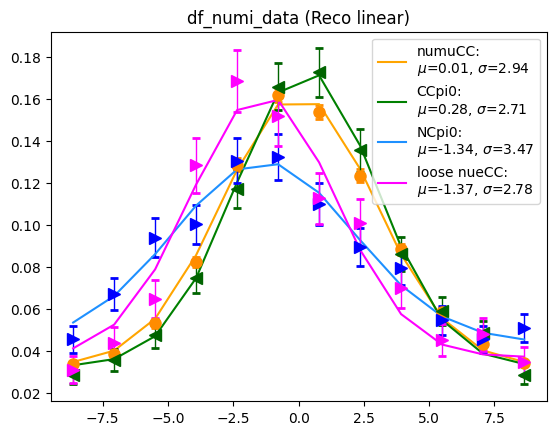

In [90]:
from scipy.optimize import curve_fit

#Definitions for some slections and signals that are usefull to examine

em_charge_scale = 0.95

#numucc signal
sig_query = "truth_isCC==1 and truth_nuPdg==14"
#numucc selection
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
# "NC" selection. mostly just the base for the cut based NCpi0 selection
NC_query = "cosmict_flag==0 and numu_score < 0"
#CC pi0 cut based selection
CCpi0_query = sel_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1* @em_charge_scale > 40 and kine_pio_energy_2* @em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_flag==1 and kine_pio_vtx_dis < 9 or kine_pio_flag==2) and kine_pio_energy_1* em_charge_scale > 40 and kine_pio_energy_2* em_charge_scale > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and pio_mass > 22 and pio_mass < 300)'
#NC pi0 BDT based selection
NCpi0_bdt_query = 'nc_pio_score > 1.816 and kine_pio_energy_1 > 0 and kine_pio_energy_2 > 0'

def gaus(x,a,x0,sigma, offset):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) + offset

def plot_time_distribution(df, time_col = "merge_time", label=""):
    nbins = 12

    # Helper for query string
    time_query = f"{time_col}>-9.42 and {time_col}<9.42"

    data_numuCC = df.query(time_query).query("numu_score>0.9")[time_col].to_numpy()
    norm1 = len(data_numuCC)
    y, xbins = np.histogram(data_numuCC, bins=nbins, range=(-9.42, 9.42))
    x1 = get_bin_centers(xbins)
    popt, pcov = curve_fit(gaus, x1, y / norm1)
    print("numuCC: Gaussian      mean:", round(popt[1], 4), "  std:", round(popt[2], 4), "  C:", round(popt[3], 4))

    data_CCpi0 = df.query(time_query).query(CCpi0_query)[time_col].to_numpy()
    norm2 = len(data_CCpi0)
    y2, xbins = np.histogram(data_CCpi0, bins=nbins, range=(-9.42, 9.42))
    x2 = get_bin_centers(xbins)
    popt2, pcov2 = curve_fit(gaus, x2, y2 / norm2)
    print("CCpi0: Gaussian      mean:", round(popt2[1], 4), "  std:", round(popt2[2], 4), "  C:", round(popt2[3], 4))

    data_NCpi0 = df.query(time_query).query(NCpi0_query)[time_col].to_numpy()
    norm3 = len(data_NCpi0)
    y3, xbins = np.histogram(data_NCpi0, bins=nbins, range=(-9.42, 9.42))
    x3 = get_bin_centers(xbins)
    popt3, pcov3 = curve_fit(gaus, x3, y3 / norm3)
    print("NCpi0: Gaussian      mean:", round(popt3[1], 4), "  std:", round(popt3[2], 4), "  C:", round(popt3[3], 4))

    data_nueCC = df.query(time_query).query("nue_score>4")[time_col].to_numpy()
    norm4 = len(data_nueCC)
    y4, xbins = np.histogram(data_nueCC, bins=nbins, range=(-9.42, 9.42))
    x4 = get_bin_centers(xbins)
    popt4, pcov4 = curve_fit(gaus, x4, y4 / norm4)
    print("loose nueCC: Gaussian      mean:", round(popt4[1], 4), "  std:", round(popt4[2], 4), "  C:", round(popt4[3], 4))

    if(time_col == "merge_time_linear_sps"):
        label = label + " (spacepoints)"
    else:
        label = label + " (Reco linear)"

    plt.figure()
    plt.title(label)
    plt.errorbar(x1, y / norm1, yerr=np.sqrt(y) / norm1, ms=8, lw=1, fmt='o', ecolor='darkorange', color='darkorange', capsize=3, capthick=2)
    plt.plot(x1, gaus(x1, *popt), color='orange', label='numuCC:' + '\n' + f"$\mu$={round(popt[1],2)}, $\\sigma$={round(abs(popt[2]),2)}")

    plt.errorbar(x2, y2 / norm2, yerr=np.sqrt(y2) / norm2, ms=8, lw=1, fmt='<', ecolor='darkgreen', color='darkgreen', capsize=3, capthick=2)
    plt.plot(x2, gaus(x2, *popt2), color='green', label='CCpi0:' + '\n' + f"$\mu$={round(popt2[1],2)}, $\\sigma$={round(abs(popt2[2]),2)}")

    plt.errorbar(x3, y3 / norm3, yerr=np.sqrt(y3) / norm3, ms=8, lw=1, fmt='>', ecolor='blue', color='blue', capsize=3, capthick=2)
    plt.plot(x3, gaus(x3, *popt3), color='dodgerblue', label='NCpi0:' + '\n' + f"$\mu$={round(popt3[1],2)}, $\\sigma$={round(abs(popt3[2]),2)}")


    plt.errorbar(x4,y4/norm4,yerr=np.sqrt(y4)/norm4,ms=8, lw=1,fmt='>',ecolor = 'magenta',color='magenta', capsize=3, capthick=2)
    plt.plot(x4,gaus(x4,*popt4),color='magenta',label='loose nueCC:'+'\n'+f"$\mu$={round(popt4[1],2)}, $\\sigma$={round(abs(popt4[2]),2)}")

    '''shift_text = f"Shifts:\nCCpi0 = {shift_ccpi0}\nNCpi0 = {shift_ncpi0}\nNue = {shift_nue}"
    plt.gcf().text(1.1, 0.2, shift_text, fontsize=12, va='center', ha='right', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    '''

    plt.legend()
    plt.show()

plot_time_distribution(overlay_df, time_col="merge_time", label="df_numi_mc")
plot_time_distribution(data_df, time_col="merge_time", label="df_numi_data")

In [91]:
'''overlay_df.to_pickle("overlay_df_with_bdt_scores1.pkl")
data_df.to_pickle("data_df_with_bdt_scores1.pkl")
dirt_df.to_pickle("dirt_df_with_bdt_scores1.pkl")
ext_df.to_pickle("ext_df_with_bdt_scores1.pkl")'''

'overlay_df.to_pickle("overlay_df_with_bdt_scores1.pkl")\ndata_df.to_pickle("data_df_with_bdt_scores1.pkl")\ndirt_df.to_pickle("dirt_df_with_bdt_scores1.pkl")\next_df.to_pickle("ext_df_with_bdt_scores1.pkl")'

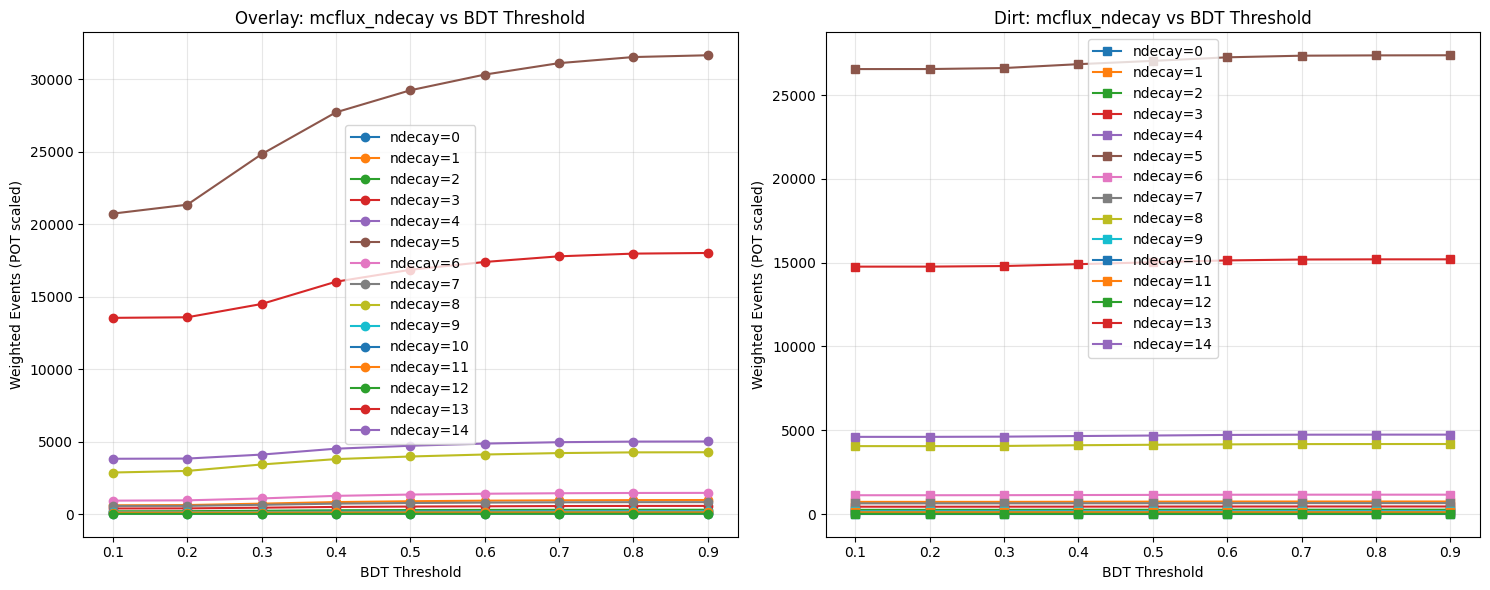

In [92]:
def plot_ndecay_by_bdt_threshold():
    """Plot mcflux_ndecay composition for overlay and dirt at different BDT thresholds"""
    bdt_var = "bdt_score"
    bdt_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Store results for plotting
    overlay_ndecay_counts = {thresh: {} for thresh in bdt_thresholds}
    dirt_ndecay_counts = {thresh: {} for thresh in bdt_thresholds}
    
    for thresh in bdt_thresholds:
        # Filter overlay by BDT
        overlay_cut = overlay_df.loc[overlay_df[bdt_var] < thresh]
        dirt_cut = dirt_df.loc[dirt_df[bdt_var] < thresh]
        
        # Get weighted counts by ndecay type
        overlay_counts = overlay_cut.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
        dirt_counts = dirt_cut.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
        
        overlay_ndecay_counts[thresh] = overlay_counts
        dirt_ndecay_counts[thresh] = dirt_counts
    
    # Plot overlay
    ax = axes[0]
    for ndecay_type in overlay_ndecay_counts[0.1].index:
        values = [overlay_ndecay_counts[t].get(ndecay_type, 0) for t in bdt_thresholds]
        ax.plot(bdt_thresholds, values, marker='o', label=f'ndecay={int(ndecay_type)}')
    
    ax.set_xlabel('BDT Threshold')
    ax.set_ylabel('Weighted Events (POT scaled)')
    ax.set_title('Overlay: mcflux_ndecay vs BDT Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot dirt
    ax = axes[1]
    for ndecay_type in dirt_ndecay_counts[0.1].index:
        values = [dirt_ndecay_counts[t].get(ndecay_type, 0) for t in bdt_thresholds]
        ax.plot(bdt_thresholds, values, marker='s', label=f'ndecay={int(ndecay_type)}')
    
    ax.set_xlabel('BDT Threshold')
    ax.set_ylabel('Weighted Events (POT scaled)')
    ax.set_title('Dirt: mcflux_ndecay vs BDT Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_ndecay_by_bdt_threshold()

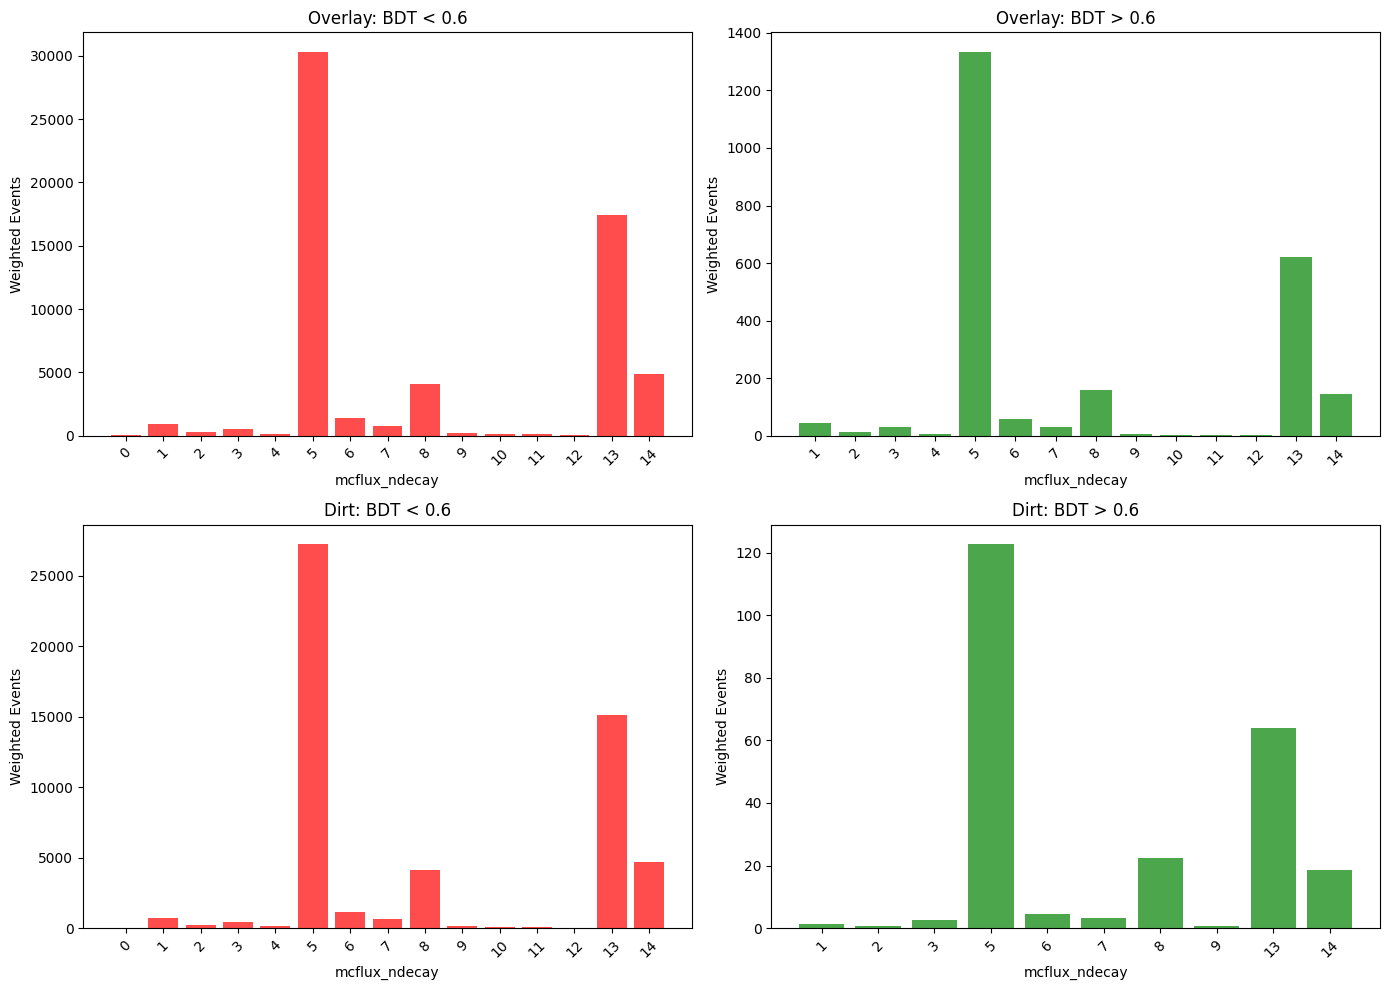


Overlay BDT < 0.6:
mcflux_ndecay
0        30.292682
1       921.809333
2       284.631029
3       532.842770
4       156.754750
5     30337.908004
6      1400.647642
7       788.230163
8      4109.151920
9       174.082073
10       90.970184
11      111.065486
12       20.196880
13    17401.838594
14     4862.838689
Name: net_weight_POTscaled, dtype: float64

Overlay BDT > 0.6:
mcflux_ndecay
1       44.609695
2       12.227095
3       28.648022
4        5.692026
5     1335.288216
6       58.954954
7       31.665980
8      156.947083
9        6.063531
10       3.899466
11       2.457758
12       1.439184
13     621.413019
14     145.773661
Name: net_weight_POTscaled, dtype: float64

Dirt BDT < 0.6:
mcflux_ndecay
0        21.556962
1       745.849774
2       257.443772
3       448.061683
4       132.579312
5     27249.714352
6      1150.316704
7       648.525392
8      4154.984128
9       163.393315
10       87.705695
11      105.332641
12       14.512143
13    15132.266486
14     4718.

In [93]:
def plot_ndecay_composition(bdt_threshold=0.6):
    """Plot ndecay composition for BDT < threshold vs BDT > threshold"""
    bdt_var = "bdt_score"
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Overlay: BDT < threshold
    overlay_low = overlay_df.loc[overlay_df[bdt_var] < bdt_threshold]
    ndecay_low = overlay_low.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
    
    # Overlay: BDT > threshold
    overlay_high = overlay_df.loc[overlay_df[bdt_var] >= bdt_threshold]
    ndecay_high = overlay_high.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
    
    # Dirt: BDT < threshold
    dirt_low = dirt_df.loc[dirt_df[bdt_var] < bdt_threshold]
    dirt_ndecay_low = dirt_low.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
    
    # Dirt: BDT > threshold
    dirt_high = dirt_df.loc[dirt_df[bdt_var] >= bdt_threshold]
    dirt_ndecay_high = dirt_high.groupby("mcflux_ndecay")["net_weight_POTscaled"].sum()
    
    # Plot overlay low BDT
    axes[0, 0].bar(ndecay_low.index.astype(str), ndecay_low.values, color='red', alpha=0.7)
    axes[0, 0].set_title(f'Overlay: BDT < {bdt_threshold}')
    axes[0, 0].set_xlabel('mcflux_ndecay')
    axes[0, 0].set_ylabel('Weighted Events')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot overlay high BDT
    axes[0, 1].bar(ndecay_high.index.astype(str), ndecay_high.values, color='green', alpha=0.7)
    axes[0, 1].set_title(f'Overlay: BDT > {bdt_threshold}')
    axes[0, 1].set_xlabel('mcflux_ndecay')
    axes[0, 1].set_ylabel('Weighted Events')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Plot dirt low BDT
    axes[1, 0].bar(dirt_ndecay_low.index.astype(str), dirt_ndecay_low.values, color='red', alpha=0.7)
    axes[1, 0].set_title(f'Dirt: BDT < {bdt_threshold}')
    axes[1, 0].set_xlabel('mcflux_ndecay')
    axes[1, 0].set_ylabel('Weighted Events')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Plot dirt high BDT
    axes[1, 1].bar(dirt_ndecay_high.index.astype(str), dirt_ndecay_high.values, color='green', alpha=0.7)
    axes[1, 1].set_title(f'Dirt: BDT > {bdt_threshold}')
    axes[1, 1].set_xlabel('mcflux_ndecay')
    axes[1, 1].set_ylabel('Weighted Events')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOverlay BDT < {bdt_threshold}:")
    print(ndecay_low)
    print(f"\nOverlay BDT > {bdt_threshold}:")
    print(ndecay_high)
    print(f"\nDirt BDT < {bdt_threshold}:")
    print(dirt_ndecay_low)
    print(f"\nDirt BDT > {bdt_threshold}:")
    print(dirt_ndecay_high)

plot_ndecay_composition(bdt_threshold=0.6)

overlay total: 16940.167873500577   breakdown sum: 16940.167873500577


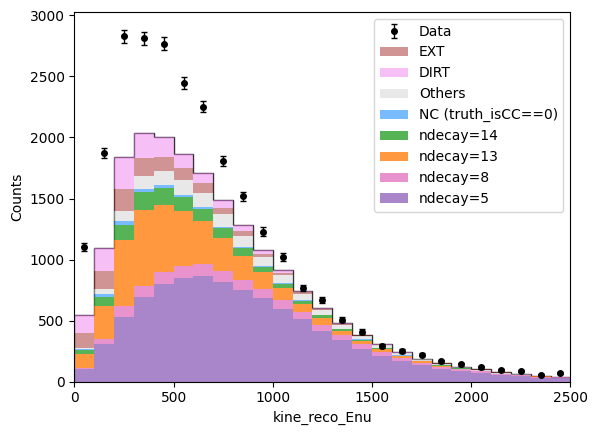

Data/MC 1.3141596250622136


In [97]:
def plot_var_breakdown_ndecay(var,nbins,min_bin,max_bin,force_legend='',add_query='',logy=False, bdt_threshold=None):

    # Make the bins
    bins = np.linspace(min_bin, max_bin, num=nbins+1)
    bdt_candidates = [
        "bdt_score"
    ]
    bdt_var = next((c for c in bdt_candidates if c in overlay_df.columns), None)
    if bdt_var is None:
        raise KeyError("No BDT score column found in overlay_df. Check overlay_df.columns.tolist().")
    
    # Make the reco selection
    query = "index>=0"
    if add_query!='': query += ' and ' + add_query 

    # Apply BDT cut to overlay - use .loc instead of .query for columns with backslashes
    if bdt_var is not None and bdt_threshold is not None:
        overlay_subset = overlay_df.query(query) if query else overlay_df
        overlay_subset = overlay_subset.loc[overlay_subset[bdt_var] < bdt_threshold]
        
        if bdt_var in data_df.columns:
            data_subset = data_df.query(query) if query else data_df
            data_subset = data_subset.loc[data_subset[bdt_var] < bdt_threshold]
        else:
            print(f"WARNING: data_df doesn't have {bdt_var}, using base query only")
            data_subset = data_df.query(query) if query else data_df
        
        if bdt_var in dirt_df.columns:
            dirt_subset = dirt_df.query(query) if query else dirt_df
            dirt_subset = dirt_subset.loc[dirt_subset[bdt_var] < bdt_threshold]
        else:
            print(f"WARNING: dirt_df doesn't have {bdt_var}, using base query only")
            dirt_subset = dirt_df.query(query) if query else dirt_df
        
        if bdt_var in ext_df.columns:
            ext_subset = ext_df.query(query) if query else ext_df
            ext_subset = ext_subset.loc[ext_subset[bdt_var] < bdt_threshold]
        else:
            print(f"WARNING: ext_df doesn't have {bdt_var}, using base query only")
            ext_subset = ext_df.query(query) if query else ext_df
    else:
        overlay_subset = overlay_df.query(query) if query else overlay_df
        data_subset = data_df.query(query) if query else data_df
        dirt_subset = dirt_df.query(query) if query else dirt_df
        ext_subset = ext_df.query(query) if query else ext_df
    
    y_overlay, x = np.histogram(
        overlay_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=overlay_subset["net_weight_POTscaled"].to_numpy(),
    )

    y_dirt, x = np.histogram(
        dirt_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=dirt_subset["net_weight_POTscaled"].to_numpy(),
    )

    y_ext, x = np.histogram(
        ext_subset[var].to_numpy(),
        bins=bins,
        density=False,
        weights=ext_subset["net_weight_POTscaled"].to_numpy(),
    )
    
    # Breakdown by mcflux_ndecay categories: 5,8,13,14, NC (truth_isCC==0), Others
    def hist_for_mask(df, mask):
        return np.histogram(df.loc[mask, var].to_numpy(), bins=bins, density=False,
                            weights=df.loc[mask, "net_weight_POTscaled"].to_numpy())[0]

    y_nd5   = hist_for_mask(overlay_subset, overlay_subset["mcflux_ndecay"] == 5)
    y_nd8   = hist_for_mask(overlay_subset, overlay_subset["mcflux_ndecay"] == 8)
    y_nd13  = hist_for_mask(overlay_subset, overlay_subset["mcflux_ndecay"] == 13)
    y_nd14  = hist_for_mask(overlay_subset, overlay_subset["mcflux_ndecay"] == 14)
    nc_mask = (overlay_subset["truth_isCC"] == 0) & (~overlay_subset["mcflux_ndecay"].isin([5,8,13,14]))
    y_nc    = hist_for_mask(overlay_subset, nc_mask)

    # Others = total overlay minus the explicitly counted categories (guard against neg small numerical issues)
    sum_known = y_nd5 + y_nd8 + y_nd13 + y_nd14 + y_nc
    y_others = y_overlay - sum_known
    y_others = np.where(y_others < 0, 0.0, y_others)

    # Sanity print: totals should match (within numerical precision)
    print("overlay total:", np.sum(y_overlay), "  breakdown sum:", np.sum(y_nd5+y_nd8+y_nd13+y_nd14+y_nc+y_others))

    # The total prediction is the sum of the three components
    y_all = np.array(y_overlay)+np.array(y_dirt)+np.array(y_ext)

    # Now same for the data - NO WEIGHTS, it's real data!
    y_data,x = np.histogram(data_subset[var].to_numpy(),bins=bins,density=False)

    # Start the plotting!
    plt.figure()     
    plt.stairs(y_all,x,color="black",alpha=0.8)

    # Stack overlay breakdown by specified categories
    baseline = np.zeros_like(y_overlay)
    plt.stairs(baseline + y_nd5, x, baseline=baseline, fill=True, color="tab:purple", label="ndecay=5", alpha=0.8); baseline += y_nd5
    plt.stairs(baseline + y_nd8, x, baseline=baseline, fill=True, color="tab:pink",   label="ndecay=8", alpha=0.8); baseline += y_nd8
    plt.stairs(baseline + y_nd13, x, baseline=baseline, fill=True, color="tab:orange", label="ndecay=13", alpha=0.8); baseline += y_nd13
    plt.stairs(baseline + y_nd14, x, baseline=baseline, fill=True, color="tab:green",  label="ndecay=14", alpha=0.8); baseline += y_nd14
    plt.stairs(baseline + y_nc, x, baseline=baseline, fill=True, color="dodgerblue", label="NC (truth_isCC==0)", alpha=0.6); baseline += y_nc
    plt.stairs(baseline + y_others, x, baseline=baseline, fill=True, color="lightgray", label="Others", alpha=0.5)

    # Add EXT and DIRT outlines/fills similarly to previous style
    plt.stairs(y_overlay+y_ext+y_dirt,x,baseline=y_overlay+y_ext,fill=True,color="violet",label="DIRT",alpha=0.5)
    plt.stairs(y_overlay+y_ext,x,baseline=y_overlay,fill=True,color="brown",label="EXT",alpha=0.5)

    plt.errorbar(get_bin_centers(x),y_data,yerr=np.sqrt(y_data),ms=8, lw=1,fmt='.',ecolor = 'black',color='black', capsize=2, capthick=1, label="Data")

    if force_legend=='outside': plt.legend(reverse=True, loc='center left', bbox_to_anchor=(1, 0.5)) 
    elif force_legend !='' and force_legend !='off': plt.legend(reverse=True, loc=force_legend)
    elif force_legend !='off': plt.legend(reverse=True)
    if logy: plt.yscale('log')
        
    plt.xlim(min_bin,max_bin)
    plt.xlabel(var)
    plt.ylabel("Counts")
    plt.show()

    print("Data/MC",np.sum(y_data)/np.sum(y_all))

plot_var_breakdown_ndecay("kine_reco_Enu",25,0,2500,force_legend='',add_query='', bdt_threshold=0.6)


overlay total: 19616.12485173191   breakdown sum: 19616.12485173191


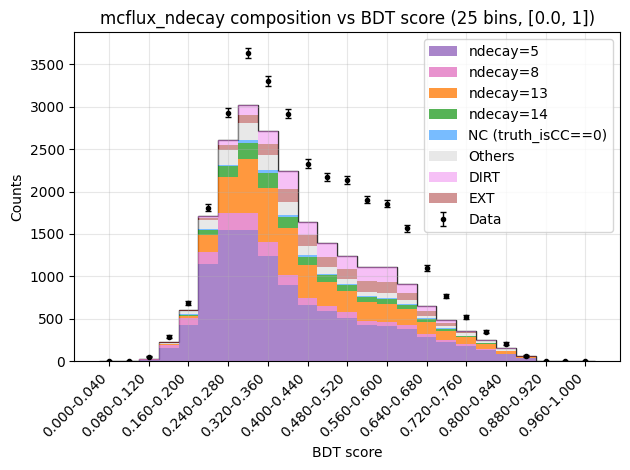

Data/MC 1.3572112887366068


In [127]:
def plot_bdt_breakdown_ndecay(num_bins=25, min_bin=0.0, max_bin=1.0, force_legend='', show_every_label=1, bdt_threshold=None):
    """
    Plot mcflux_ndecay composition vs BDT score (x axis = BDT between min_bin and max_bin).
    Styled to match plot_var_breakdown_ndecay visual style (stacked stairs, EXT/DIRT fills, data points).
    """
    bdt_var = "bdt_score"
    bins = np.linspace(min_bin, max_bin, num=num_bins + 1)
    centers = bins[:-1] + (bins[1] - bins[0]) / 2.0

    # prepare subsets (apply optional bdt_threshold as an extra selection)
    overlay_subset = overlay_df.copy()
    data_subset = data_df.copy()
    dirt_subset = dirt_df.copy()
    ext_subset = ext_df.copy()
    
    overlay_subset = overlay_subset.loc[overlay_subset["kine_reco_Enu"] > 0]
    data_subset = data_subset.loc[data_subset["kine_reco_Enu"] > 0]
    dirt_subset = dirt_subset.loc[dirt_subset["kine_reco_Enu"] > 0]
    ext_subset = ext_subset.loc[ext_subset["kine_reco_Enu"] > 0]

    if bdt_threshold is not None:
        overlay_subset = overlay_subset.loc[overlay_subset[bdt_var] > bdt_threshold]
        data_subset = data_subset.loc[data_subset[bdt_var] > bdt_threshold] if bdt_var in data_subset.columns else data_subset
        dirt_subset = dirt_subset.loc[dirt_subset[bdt_var] > bdt_threshold] if bdt_var in dirt_subset.columns else dirt_subset
        ext_subset  = ext_subset.loc[ext_subset[bdt_var] > bdt_threshold] if bdt_var in ext_subset.columns else ext_subset

    # helper for weighted histogram counts over BDT bins
    def hist_vals(df, arr_col, weight_col=None):
        arr = df[arr_col].to_numpy() if arr_col in df.columns else np.array([])
        w = df[weight_col].to_numpy() if (weight_col is not None and weight_col in df.columns) else None
        if len(arr) == 0:
            return np.zeros(len(bins) - 1)
        return np.histogram(arr, bins=bins, weights=w)[0]

    # totals
    y_overlay = hist_vals(overlay_subset, bdt_var, "net_weight_POTscaled")
    y_dirt    = hist_vals(dirt_subset,    bdt_var, "net_weight_POTscaled")
    y_ext     = hist_vals(ext_subset,     bdt_var, "net_weight_POTscaled")

    # breakdown by mcflux_ndecay categories: 5,8,13,14, NC (truth_isCC==0), Others
    y_nd5  = hist_vals(overlay_subset.loc[overlay_subset["mcflux_ndecay"] == 5],  bdt_var, "net_weight_POTscaled")
    y_nd8  = hist_vals(overlay_subset.loc[overlay_subset["mcflux_ndecay"] == 8],  bdt_var, "net_weight_POTscaled")
    y_nd13 = hist_vals(overlay_subset.loc[overlay_subset["mcflux_ndecay"] == 13], bdt_var, "net_weight_POTscaled")
    y_nd14 = hist_vals(overlay_subset.loc[overlay_subset["mcflux_ndecay"] == 14], bdt_var, "net_weight_POTscaled")
    nc_mask = (overlay_subset["truth_isCC"] == 0) & (~overlay_subset["mcflux_ndecay"].isin([5,8,13,14]))
    y_nc   = hist_vals(overlay_subset.loc[nc_mask], bdt_var, "net_weight_POTscaled")

    sum_known = y_nd5 + y_nd8 + y_nd13 + y_nd14 + y_nc
    y_others = y_overlay - sum_known
    y_others = np.where(y_others < 0, 0.0, y_others)

    print("overlay total:", np.sum(y_overlay), "  breakdown sum:", np.sum(sum_known + y_others))

    # total prediction
    y_all = y_overlay + y_dirt + y_ext

    # data histogram (unweighted)
    if bdt_var in data_subset.columns:
        y_data = np.histogram(data_subset[bdt_var].to_numpy(), bins=bins)[0]
    else:
        y_data = np.zeros(len(bins)-1)

    # Start plotting (match style of plot_var_breakdown_ndecay)
    plt.figure()
    x = bins

    # Outline total
    plt.stairs(y_all, x, color="black", alpha=0.8)

    # Stack overlay breakdown by specified categories using stairs and baseline accumulation
    baseline = np.zeros_like(y_overlay)
    plt.stairs(baseline + y_nd5, x, baseline=baseline, fill=True, color="tab:purple", label="ndecay=5", alpha=0.8); baseline += y_nd5
    plt.stairs(baseline + y_nd8, x, baseline=baseline, fill=True, color="tab:pink",   label="ndecay=8", alpha=0.8); baseline += y_nd8
    plt.stairs(baseline + y_nd13, x, baseline=baseline, fill=True, color="tab:orange", label="ndecay=13", alpha=0.8); baseline += y_nd13
    plt.stairs(baseline + y_nd14, x, baseline=baseline, fill=True, color="tab:green",  label="ndecay=14", alpha=0.8); baseline += y_nd14
    plt.stairs(baseline + y_nc, x, baseline=baseline, fill=True, color="dodgerblue", label="NC (truth_isCC==0)", alpha=0.6); baseline += y_nc
    plt.stairs(baseline + y_others, x, baseline=baseline, fill=True, color="lightgray", label="Others", alpha=0.5)

    # Add EXT and DIRT outlines/fills similarly to previous style (use overlay+y_ext, overlay+y_ext+y_dirt)
    plt.stairs(y_overlay + y_ext + y_dirt, x, baseline=y_overlay + y_ext, fill=True, color="violet", label="DIRT", alpha=0.5)
    plt.stairs(y_overlay + y_ext, x, baseline=y_overlay, fill=True, color="brown", label="EXT", alpha=0.5)

    # Data points
    plt.errorbar(centers, y_data, yerr=np.sqrt(y_data), ms=6, lw=1, fmt='.', ecolor='black', color='black', capsize=2, capthick=1, label="Data")

    # xticks
    if show_every_label <= 0: show_every_label = 1
    bin_labels = [f"{bins[i]:.3f}-{bins[i+1]:.3f}" for i in range(len(bins)-1)]
    plt.xticks(centers[::show_every_label], [bin_labels[i] for i in range(0, len(bin_labels), show_every_label)], rotation=45, ha='right')

    plt.xlabel('BDT score')
    plt.ylabel('Counts')
    plt.title(f"mcflux_ndecay composition vs BDT score ({num_bins} bins, [{min_bin}, {max_bin}])")

    if force_legend == 'outside':
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    elif force_legend:
        plt.legend(loc=force_legend)
    else:
        plt.legend()

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Data/MC", np.sum(y_data) / np.sum(y_all) if np.sum(y_all) > 0 else np.nan)

plot_bdt_breakdown_ndecay(num_bins=25, min_bin=0.0, max_bin=1, force_legend='', show_every_label=2)

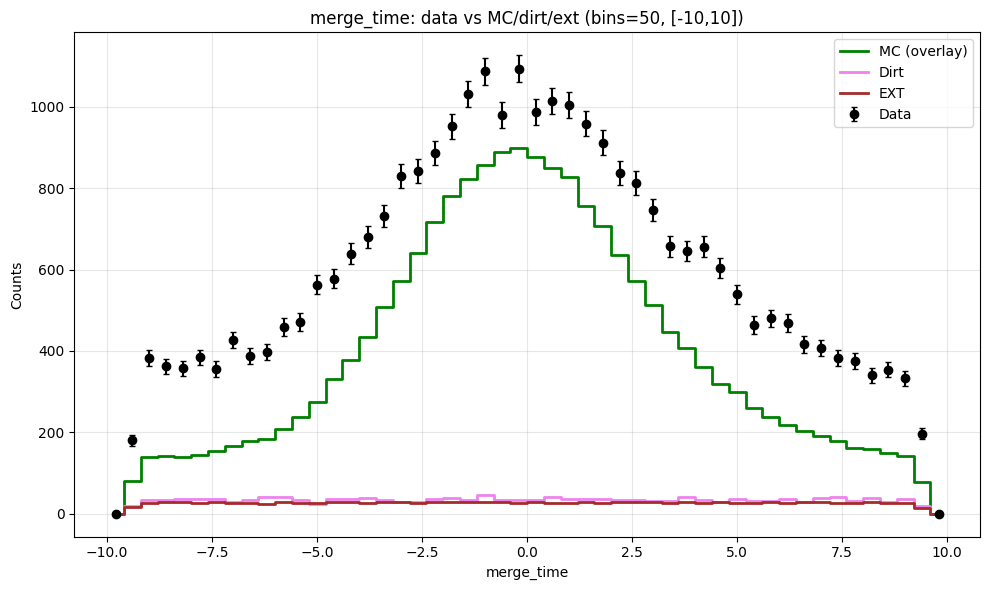

Totals: Data 29656.00, MC 19431.79, Dirt 1625.98, EXT 1298.97


In [120]:
# ...existing code...
def plot_merge_time_components(nbins=50, min_bin=-10, max_bin=10, normalize=False, logy=False, require_positive_kine=True):
    var = "merge_time"
    bins = np.linspace(min_bin, max_bin, num=nbins + 1)
    centers = get_bin_centers(bins)

    # apply kine_reco_Enu>0 selection if requested
    if require_positive_kine:
        overlay_sel = overlay_df.loc[overlay_df["kine_reco_Enu"] > 0]
        dirt_sel    = dirt_df.loc[dirt_df["kine_reco_Enu"] > 0]
        ext_sel     = ext_df.loc[ext_df["kine_reco_Enu"] > 0]
        data_sel    = data_df.loc[data_df["kine_reco_Enu"] > 0]
    else:
        overlay_sel, dirt_sel, ext_sel, data_sel = overlay_df, dirt_df, ext_df, data_df

    # histograms: overlay (MC), dirt, ext weighted; data unweighted
    y_mc, _   = np.histogram(overlay_sel[var].to_numpy(), bins=bins, weights=overlay_sel["net_weight_POTscaled"].to_numpy())
    y_dirt, _ = np.histogram(dirt_sel[var].to_numpy(),    bins=bins, weights=dirt_sel["net_weight_POTscaled"].to_numpy())
    y_ext, _  = np.histogram(ext_sel[var].to_numpy(),     bins=bins, weights=ext_sel["net_weight_POTscaled"].to_numpy())
    y_data, _ = np.histogram(data_sel[var].to_numpy(),    bins=bins)  # data is real, no weights

    if normalize:
        denom_mc = np.sum(y_mc) if np.sum(y_mc) > 0 else 1.0
        denom_dirt = np.sum(y_dirt) if np.sum(y_dirt) > 0 else 1.0
        denom_ext = np.sum(y_ext) if np.sum(y_ext) > 0 else 1.0
        denom_data = np.sum(y_data) if np.sum(y_data) > 0 else 1.0
        y_mc  = y_mc  / denom_mc
        y_dirt = y_dirt/ denom_dirt
        y_ext = y_ext / denom_ext
        y_data = y_data / denom_data

    plt.figure(figsize=(10,6))
    plt.step(centers, y_mc,  where='mid', label='MC (overlay)', color='green', linewidth=2)
    plt.step(centers, y_dirt, where='mid', label='Dirt', color='violet', linewidth=2)
    plt.step(centers, y_ext,  where='mid', label='EXT', color='brown', linewidth=2)
    plt.errorbar(centers, y_data, yerr=np.sqrt(y_data) if not normalize else np.sqrt(y_data), fmt='o', color='black', label='Data', capsize=2)

    plt.xlabel('merge_time')
    plt.ylabel('Counts' if not normalize else 'Normalized')
    plt.title(f'merge_time: data vs MC/dirt/ext (bins={nbins}, [{min_bin},{max_bin}])')
    if logy: plt.yscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Totals: Data {:.2f}, MC {:.2f}, Dirt {:.2f}, EXT {:.2f}".format(np.sum(y_data), np.sum(y_mc), np.sum(y_dirt), np.sum(y_ext)))

# ...existing code...

plot_merge_time_components()

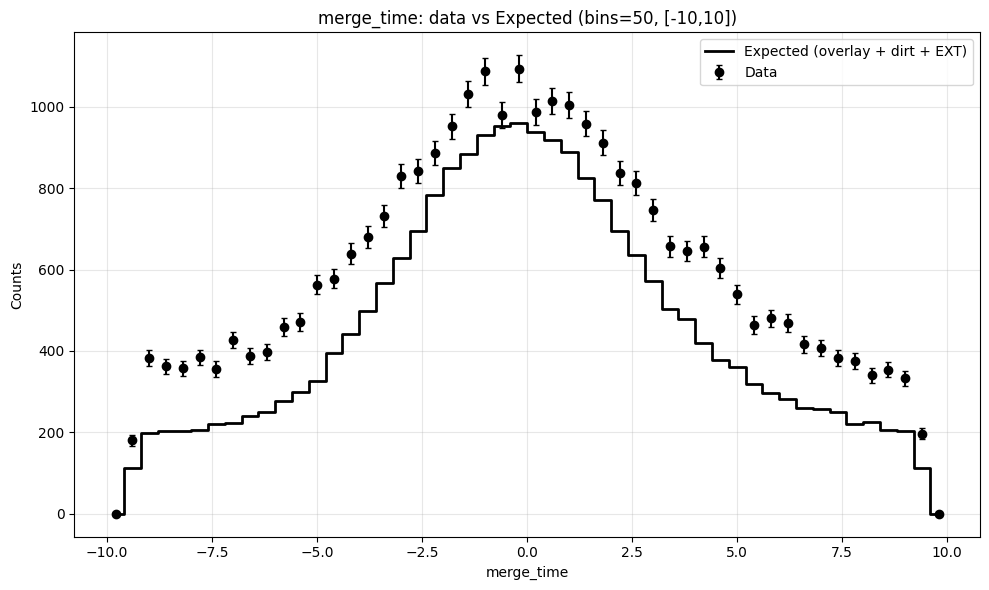

Totals: Data 29656.00, Expected 22356.74 (MC 19431.79, Dirt 1625.98, EXT 1298.97)


In [ ]:
# ...existing code...
def plot_merge_time_components(nbins=50, min_bin=-10, max_bin=10, normalize=False, logy=False, require_positive_kine=True):
    var = "merge_time"
    bins = np.linspace(min_bin, max_bin, num=nbins + 1)
    centers = np.array(get_bin_centers(bins))

    # apply kine_reco_Enu>0 selection if requested
    if require_positive_kine:
        overlay_sel = overlay_df.loc[overlay_df["kine_reco_Enu"] > 0]
        dirt_sel    = dirt_df.loc[dirt_df["kine_reco_Enu"] > 0]
        ext_sel     = ext_df.loc[ext_df["kine_reco_Enu"] > 0]
        data_sel    = data_df.loc[data_df["kine_reco_Enu"] > 0]
    else:
        overlay_sel, dirt_sel, ext_sel, data_sel = overlay_df, dirt_df, ext_df, data_df

    # histograms: overlay (MC), dirt, ext weighted; data unweighted
    y_mc, _   = np.histogram(overlay_sel[var].to_numpy(), bins=bins, weights=overlay_sel.get("net_weight_POTscaled", np.ones(len(overlay_sel))).to_numpy())
    y_dirt, _ = np.histogram(dirt_sel[var].to_numpy(),    bins=bins, weights=dirt_sel.get("net_weight_POTscaled", np.ones(len(dirt_sel))).to_numpy())
    y_ext, _  = np.histogram(ext_sel[var].to_numpy(),     bins=bins, weights=ext_sel.get("net_weight_POTscaled", np.ones(len(ext_sel))).to_numpy())
    y_data, _ = np.histogram(data_sel[var].to_numpy(),    bins=bins)  # data is real, no weights

    # combined expected = overlay + dirt + ext
    y_expected = y_mc + y_dirt + y_ext

    if normalize:
        denom = np.sum(y_expected) if np.sum(y_expected) > 0 else 1.0
        y_expected = y_expected / denom
        y_data = y_data / (np.sum(y_data) if np.sum(y_data) > 0 else 1.0)

    plt.figure(figsize=(10,6))
    plt.step(centers, y_expected, where='mid', label='Expected (overlay + dirt + EXT)', color='black', linewidth=2)
    plt.errorbar(centers, y_data, yerr=np.sqrt(y_data) if not normalize else np.sqrt(y_data), fmt='o', color='black', label='Data', capsize=2)

    plt.xlabel('merge_time')
    plt.ylabel('Counts' if not normalize else 'Normalized')
    plt.title(f'merge_time: data vs Expected (bins={nbins}, [{min_bin},{max_bin}])')
    if logy: plt.yscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Totals: Data {:.2f}, Expected {:.2f} (MC {:.2f}, Dirt {:.2f}, EXT {:.2f})".format(
        np.sum(y_data), np.sum(y_expected), np.sum(y_mc), np.sum(y_dirt), np.sum(y_ext)))
# ...existing code...

plot_merge_time_components()

MemoryError: Unable to allocate 5.07 MiB for an array with shape (664130, 1) and data type float64

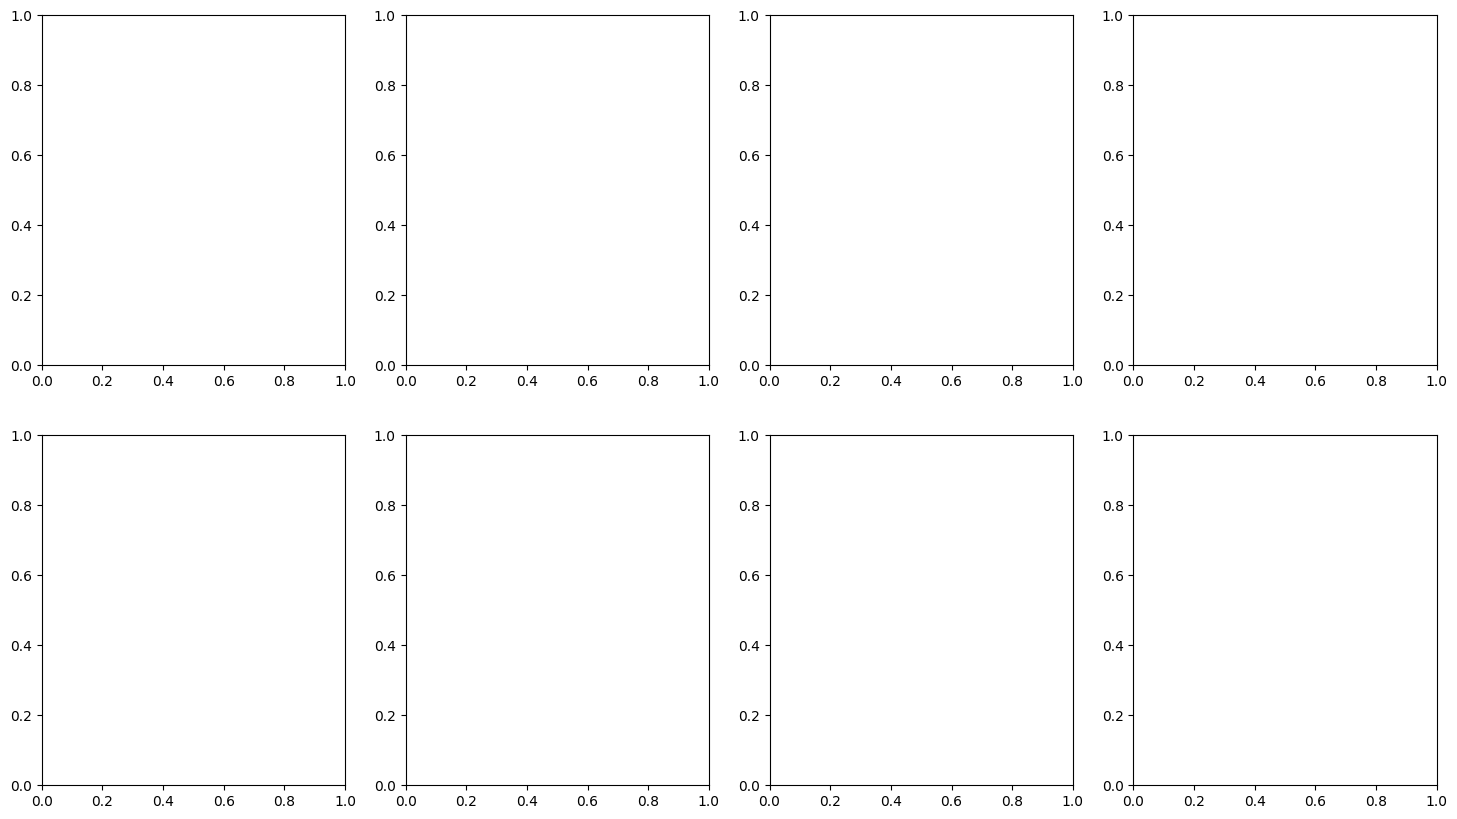

In [130]:
def plot_merge_time_by_run_bins_no_shifts():
    """Plot merge_time distribution for data_df split by run number bins (no shifts)"""
    run_bins = [
        (24400, 25800, "Run 24400-25800"),
    ]

    nbins = 50
    min_bin = -10
    max_bin = 10
    bins = np.linspace(min_bin, max_bin, num=nbins + 1)

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for idx, (run_min, run_max, label) in enumerate(run_bins):
        data_subset = data_df.loc[(data_df["run"] > run_min) & (data_df["run"] <= run_max)].copy()
        y, x = np.histogram(
            data_subset["merge_time"].to_numpy(),
            bins=bins,
            density=False
        )
        axes[idx].stairs(y, x, fill=True, color='blue', alpha=0.7)
        axes[idx].set_title(f'{label}\\n(N={data_subset.shape[0]} events)')
        axes[idx].set_xlabel('merge_time (µs)')
        axes[idx].set_ylabel('Counts')
        axes[idx].set_xlim(min_bin, max_bin)
        axes[idx].grid(True, alpha=0.3)
        print(f"{label}: {data_subset.shape[0]} events, mean merge_time = {data_subset['merge_time'].mean():.4f}")

    plt.tight_layout()
    plt.show()

plot_merge_time_by_run_bins_no_shifts()
#add_bdt_scores(data_df, model_VtxAct, model_features, "newbdt\flux_vz_gt500")

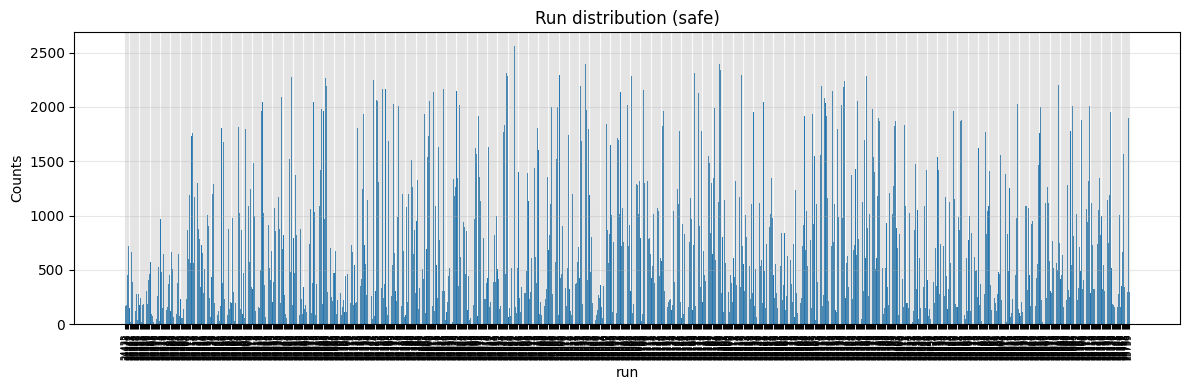

In [135]:
# ...existing code...
# Memory-safe run distribution plot (replace plt.hist(data_df["run"]))
def safe_extract_run(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (list, tuple, np.ndarray)):
        return val[0] if len(val) > 0 else np.nan
    return val

# extract scalar run values without forcing large numpy arrays
run_series = data_df["run"].apply(safe_extract_run)
run_numeric = pd.to_numeric(run_series, errors="coerce").dropna().astype(int)

# restrict to ranges (set run_ranges = [] to use all runs)
run_ranges = [(24400, 25800)]
if run_ranges:
    mask = pd.Series(False, index=run_numeric.index)
    for rmin, rmax in run_ranges:
        mask |= (run_numeric > rmin) & (run_numeric <= rmax)
    run_numeric = run_numeric.loc[mask]

# use value_counts (memory-efficient) and plot
vc = run_numeric.value_counts().sort_index()

plt.figure(figsize=(12,4))
plt.bar(vc.index.astype(str), vc.values, width=0.8)
# reduce xtick clutter if many runs
if len(vc) > 50:
    plt.xticks(rotation=90, fontsize=6)
else:
    plt.xticks(rotation=90)
plt.xlabel("run")
plt.ylabel("Counts")
plt.title("Run distribution (safe)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ...existing code...

(array([   89.,     0.,     0.,     0.,  2856.,  1983.,  2833.,  3642.,
         3075.,  7757.,  7415.,  6355.,  4253.,     0.,  1351.,  4830.,
         9009.,  9390.,  8037., 10447.,  4761.,  8478., 12951.,  4110.,
         5263.,  7758.,  9094.,  7526., 10490.,  8157.,  8361., 10717.,
         7210., 11723.,  2874.,  7997.,  4012.,     0.,     0.,  5216.,
        10596.,  5851.,  6628.,  7091.,  7346., 10067.,  6692., 12374.,
         4803.,  7645., 11636.,  7977.,  7972.,  7957.,  7860.,  8248.,
         3925., 11580.,  8919., 14443.,  9671.,  6946.,  5821.,  7465.,
         6286.,  8631.,  8840.,  5066., 14025., 12763., 11770.,  8258.,
        12878.,  7548.,  8550.,  4519.,  2175.,  5721.,     0.,     0.,
            0.,     0.,     0.,  6870.,  8129.,  7888.,  9431.,  8249.,
         3694.,  4118.,  5209.,  7577., 10698.,  2452.,  8867.,  9104.,
        11214.,  8983.,  6635.,  8538.]),
 array([24376.  , 24389.83, 24403.66, 24417.49, 24431.32, 24445.15,
        24458.98, 24472.81

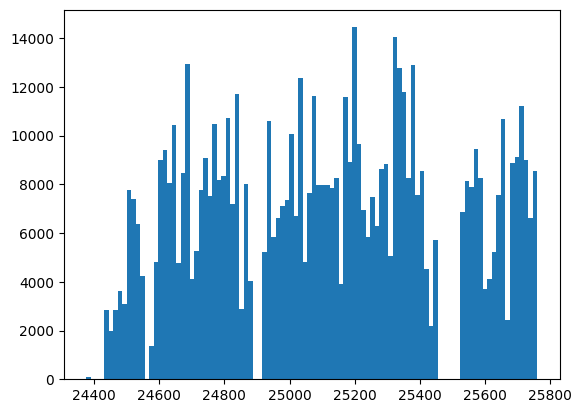

In [132]:
plt.hist(data_df["run"], bins=100)


dtype: int32
min/max: 24376 25759
n unique runs: 908
value_counts (top 50):
run
24951    2559
25198    2396
25036    2396
25199    2339
25169    2314
24942    2314
25573    2311
24709    2311
25005    2296
25218    2292
25090    2289
25366    2289
24943    2282
24649    2278
24687    2262
25183    2260
24743    2245
25340    2236
25731    2217
25680    2203
25031    2196
25316    2194
24689    2189
25339    2187
24824    2167
24761    2165
24755    2164
25559    2164
25107    2158
24840    2147
25327    2146
25076    2142
24811    2136
25172    2125
24639    2087
25320    2085
24747    2062
24749    2052
25353    2051
24808    2051
25243    2048
24621    2043
24675    2041
25321    2035
25626    2025
24770    2025
25085    2022
24605    2016
24843    2015
25337    2014
Name: count, dtype: int64
unique runs (sorted, first 200):
[24376 24435 24437 24438 24440 24441 24442 24443 24444 24445 24446 24447
 24448 24450 24451 24452 24453 24455 24456 24457 24458 24459 24460 24461
 24462 24463 24

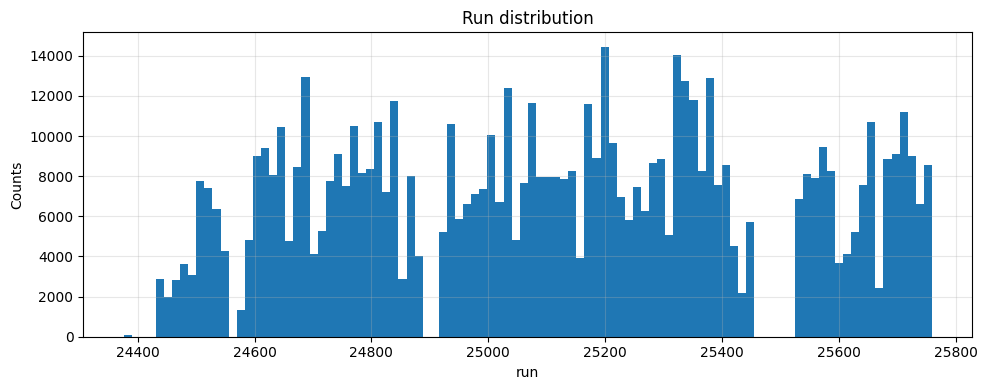

In [133]:
# ...existing code...
print("dtype:", data_df["run"].dtype)
print("min/max:", data_df["run"].min(), data_df["run"].max())
print("n unique runs:", data_df["run"].nunique())
print("value_counts (top 50):")
print(data_df["run"].value_counts().head(50))
print("unique runs (sorted, first 200):")
print(np.sort(data_df["run"].unique())[:200])

plt.figure(figsize=(10,4))
plt.hist(data_df["run"].dropna(), bins=100)
plt.xlabel("run")
plt.ylabel("Counts")
plt.title("Run distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ...existing code...

In [ ]:
'''pd.to_pickle(data_df, "run5_data_df.pkl")
pd.to_pickle(overlay_df, "run5_overlay_df.pkl")
pd.to_pickle(dirt_df, "run5_dirt_df.pkl")
pd.to_pickle(ext_df, "run5_ext_df.pkl")'''